In [NumPy and pandas in a Real Workflow](numpy_pandas_workflow.ipynb), you carried one
table through cleaning, calculation, and checking, and every answer came back as
numbers. A table of numbers tells you what the values *are*. A plot tells you what they
*do* — whether they cluster, spread out, drift upward, or split into groups. Almost every
question you will ask of a dataset in this course is easier to answer with a picture
first.

This chapter has two goals:

1. **Choosing** the right kind of plot for the question you are asking.
2. **Drawing** that plot three different ways — with `pandas`, with `matplotlib`, and
   with `seaborn` — so you understand how the three libraries relate to each other.

Every plot in this chapter is a *single* plot: one set of axes, one picture. Putting
several plots side by side in one figure is the subject of the next chapter.

By the end of this chapter you should be able to:

- Choose a plot from the question you are asking and the types of the variables involved, rather than from habit.
- Draw the same plot with `pandas`, `matplotlib`, and `seaborn`, and say what each library contributes.
- Read a histogram as a choice about bins, and describe how the bin count changes the story it tells.
- Compare a histogram with its two relatives, the density curve and the box plot, and say what each one hides.
- Add a third or fourth variable with `hue`, `style`, and `size`, and recognize when one set of axes is carrying too much.
- Interpret a correlation table and its heatmap, and fit a regression line only where a line belongs.
- Name the aggregation a plotting function performed for you when you never asked for one.
- Report how many observations a plot left out, since all three libraries drop missing values silently.
- Label, size, and theme a finished plot, and judge whether it makes an honest argument.

Complete the [practice activity](#practice-activity-choose-draw-and-defend-a-plot)
after the worked examples.

## Set Up Your Chapter Files {#set-up-your-chapter-files}

Download the [Data Visualization I practice kit](downloads/data-visualization-1-practice.zip).
Extract `stat303-data-visualization-1` inside the `stat303-setup` project from the setup
chapters and select that project's verified Python environment.

```text
stat303-setup/
├── .venv/
└── stat303-data-visualization-1/
    ├── data_viz_1_examples.ipynb
    ├── activity08.ipynb
    └── README.md
```

Run `data_viz_1_examples.ipynb` for the lesson and complete `activity08.ipynb` for your own
activity report, with `stat303-data-visualization-1` as the notebook working folder.

**This kit has no `data/` folder, and nothing belongs in one.** Every plot in the chapter
and in the practice work uses the Palmer penguins dataset that comes with seaborn, which
`sns.load_dataset("penguins")` hands you in one line. The first call downloads the file
and caches it on your computer, so you need a network connection once; after that it
loads from the cache. If you would rather read it from a file of your own, the note under
[The data](#the-data) shows the one-line change.

We need three libraries. The import aliases below (`pd`, `plt`, `sns`) are near-universal
conventions — you will see them in every textbook, tutorial, and Stack Overflow answer,
so use them.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Environment check:** This chapter uses pandas, matplotlib, and seaborn. If an import
fails, check the selected notebook kernel first. If a package is missing, activate your
project environment and run this command in its terminal:

```bash
python -m pip install pandas matplotlib seaborn
```

pandas and matplotlib went into that environment in
[Project Environments, Packages, and File Paths](python_venv.ipynb#install-packages-in-the-intended-environment),
and seaborn is the package that chapter installs as its worked example.

## The data

We will use the **Palmer penguins** dataset throughout. It records body measurements for
344 penguins observed near Palmer Station, Antarctica. `seaborn` ships with it, so we can
load it in one line.

In [2]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


::: {.callout-note}
## Loading the data from a file instead

`sns.load_dataset` downloads the data over the internet. If you have the file saved
locally as `penguins.csv`, use what you already know instead:
`df = pd.read_csv("penguins.csv")`. Everything after this point is identical.
:::

Before plotting anything, look at the shape of the data and the type of each column.

In [3]:
print(df.shape)
df.dtypes

(344, 7)


species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

So we have 344 rows and 7 columns. The column types fall into two groups, and this
distinction is the single most important thing for choosing a plot:

- **Numeric** (`float64`): `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
  `body_mass_g`. These are measured quantities. Arithmetic on them is meaningful — an
  average body mass is a sensible thing to compute.
- **Categorical** (text, reported as `object` or `str` depending on your pandas version):
  `species`, `island`, `sex`. These are labels that sort penguins into groups. There are
  only a handful of distinct values, and arithmetic on them is meaningless.

Here are the categories:

In [4]:
print(df["species"].value_counts())
print(df["island"].value_counts())
print(df["sex"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
sex
Male      168
Female    165
Name: count, dtype: int64


Notice the counts for `sex` add up to 333, not 344. Some values are missing. We can see
exactly how many are missing in each column:

In [5]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

::: {.callout-important}
## Missing values and plots

Eleven penguins have no recorded sex, and two have no body measurements at all. All three
plotting libraries **silently drop missing values** when they draw. That is usually what
you want, but it means the number of observations in a plot can be smaller than the
number of rows in your data — and nothing on the plot tells you so. Whenever you plot a
column with missing values, it is your job to know how many were dropped.
:::

## Choosing a plot

Do not start by asking "what plot should I make?" Start by asking **what question you
want answered**, then let the *types* of the variables involved pick the plot for you.

That gives you a small decision table. Nearly everything in an introductory course fits
in it:

| Variables involved | Question you are asking | Plot to use |
|---|---|---|
| One numeric | How are these values distributed? | **Histogram**, density plot, or boxplot |
| One categorical | How many observations in each group? | **Bar chart** of counts |
| Two numeric | Do these two move together? | **Scatter plot** |
| Two numeric, roughly linear | How strong is the trend, and how steep? | **Scatter plot with a regression line** |
| Two numeric, one ordered (e.g. time) | How does this change along the other? | **Line plot** |
| Several numeric | Which pairs move together? | **Correlation heatmap** |
| One numeric, one categorical | Does this quantity differ across groups? | **Grouped boxplot**, violin, or bar of means |
| Two categorical | Are these two groupings related? | **Grouped bar chart** or heatmap of counts |

Two rules of thumb that will save you from most bad plots:

- **Count the variables.** One variable is a distribution. Two variables is a
  relationship. Three or more means you need a color, shape, or extra panel to carry the
  extra variable — and past three, it is usually clearer to draw more than one plot.
- **A line implies a connection.** Use a line plot only when the x-values have a
  meaningful order, so that "between" two points means something. Species names have no
  order, so connecting them with a line would be inventing structure that isn't there.

The rest of this chapter works down that table, row by row.

## The three libraries

All three libraries draw the same kinds of plots. They differ in how much you have to
say to get them.

**`matplotlib`** is the foundation. It draws the pixels. Everything is under your control,
which also means everything is your responsibility — axis labels, titles, and colors are
all separate commands. Both of the other libraries are built on top of it.

**`pandas`** adds a `.plot()` method directly to DataFrames and Series. It calls
`matplotlib` for you and reads the labels off your column names. It is the fastest way to
get a quick look at data you already have in a DataFrame, and it is meant for exactly
that: a quick look.

**`seaborn`** is also built on `matplotlib`, but it is designed around *statistical*
plots of tidy DataFrames. You name the DataFrame and the columns; it handles grouping,
aggregation, binning, and legends. It is the best choice when a plot involves groups or
requires computing something (a mean, a distribution, a regression line).

A rough guide to which to reach for:

| Situation | Use |
|---|---|
| Quick look at a column, mid-analysis | `pandas` |
| Plot involving groups, distributions, or statistics | `seaborn` |
| Full control over an unusual or heavily customized plot | `matplotlib` |
| Data not in a DataFrame (plain lists or arrays) | `matplotlib` |

You will end up mixing them, and that is fine — because `pandas` and `seaborn` both draw
*through* `matplotlib`, `matplotlib` commands like `plt.title()` work on plots the other
two libraries made. We rely on that repeatedly below.

::: {.callout-tip}
## Why some cells end in `plt.show()`

In a notebook, a plot appears as soon as a cell finishes. But `pandas` and `seaborn`
plotting calls also *return* an object, and the notebook prints it — you get a stray
line like `<Axes: xlabel='body_mass_g'>` above your figure. Ending the cell with
`plt.show()` displays the plot and suppresses that line. (A semicolon after the last
command, e.g. `sns.histplot(...);`, does the same thing.) In a `.py` script, `plt.show()`
is not optional: without it, no window ever opens.
:::

## One numeric variable: the histogram

**Question:** how heavy are these penguins? Are most of them around the same mass, or is
there a wide spread?

One numeric variable means we want its **distribution**. A histogram answers this by
cutting the range of values into bins and counting how many observations fall in each.

### With pandas

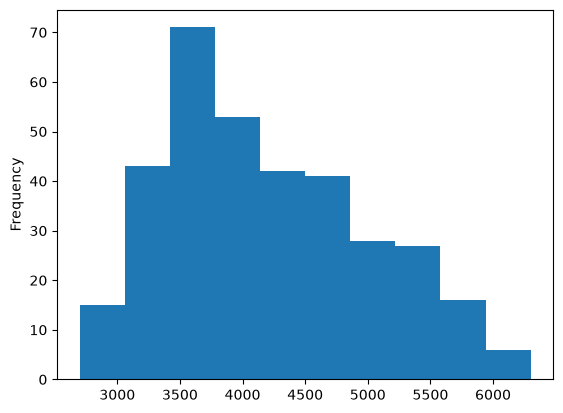

In [6]:
df["body_mass_g"].plot(kind="hist")
plt.show()

`df["body_mass_g"]` selects a single column (a Series), and `.plot(kind="hist")` draws it.
That is the whole command. Note that the y-axis is already labeled `Frequency` — pandas
filled that in.

### With matplotlib

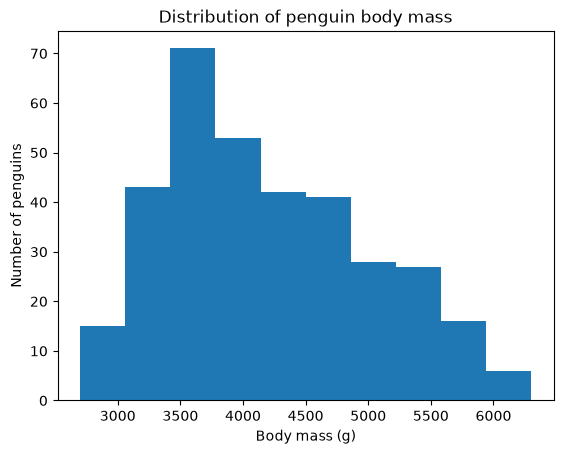

In [7]:
plt.hist(df["body_mass_g"])
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.title("Distribution of penguin body mass")
plt.show()

`matplotlib` draws exactly what you ask for and nothing more, so the labels are three
extra commands. This is the trade-off: more typing, total control.

### With seaborn

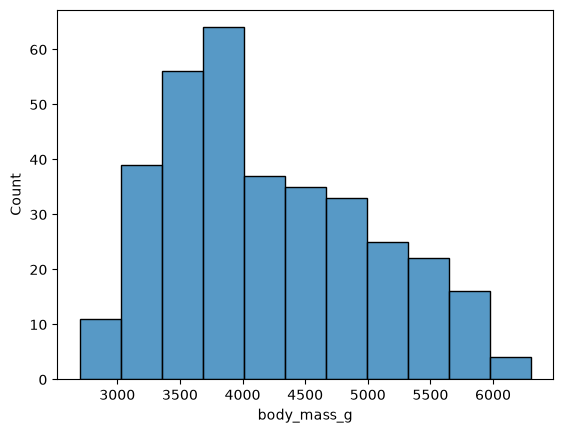

In [8]:
sns.histplot(data=df, x="body_mass_g")
plt.show()

Notice the pattern in that call, because **every seaborn function in this chapter uses
it**:

```
sns.plotting_function(data=<DataFrame>, x=<column name>, y=<column name>)
```

You pass the whole DataFrame to `data` and then name columns as *strings*. Seaborn looks
them up and labels the axes from the column names automatically.

### Bins: the one choice that matters

A histogram's shape depends on how many bins you use, and the default is only a guess.
Too few bins hides structure; too many turns the plot into noise. This is not a cosmetic
setting — **the number of bins can change the conclusion you draw.**

To see that happen, switch to a different column, `bill_length_mm`, and draw it three
times.

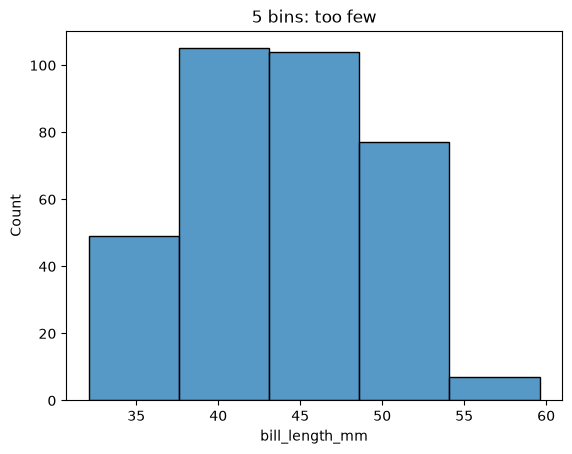

In [9]:
sns.histplot(data=df, x="bill_length_mm", bins=5)
plt.title("5 bins: too few")
plt.show()

Five bins says bill length has one broad plateau between 40 mm and 50 mm. Now look more
finely:

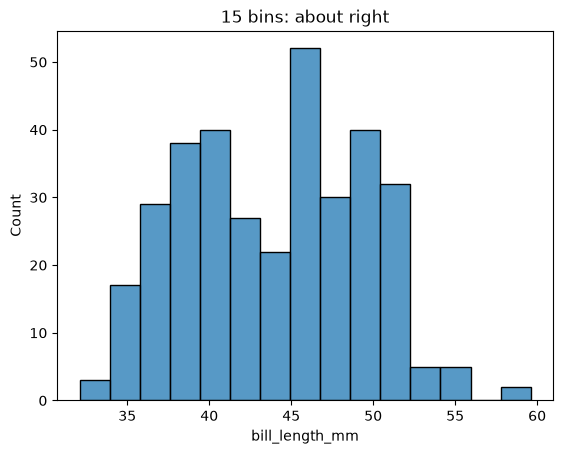

In [10]:
sns.histplot(data=df, x="bill_length_mm", bins=15)
plt.title("15 bins: about right")
plt.show()

That is a different story entirely. There are **two peaks** — one near 39 mm and one near
48 mm — with a dip between them around 43 mm. A distribution with two peaks is called
*bimodal*, and it almost always means the data contains two distinct groups that have
been mixed together. The five-bin version hid this completely.

Push further and the structure dissolves:

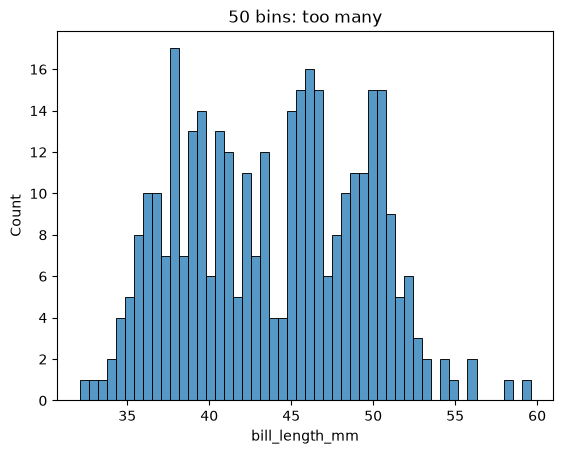

In [11]:
sns.histplot(data=df, x="bill_length_mm", bins=50)
plt.title("50 bins: too many")
plt.show()

With 50 bins there are only a handful of penguins per bin, so random variation dominates
and the bars jump up and down. The two peaks are still in there, but you would be
guessing.

The lesson: **always redraw a histogram with a couple of different bin counts** before
you trust its shape. If a feature survives at several settings it is probably real; if it
appears at only one setting it probably isn't. A good starting range for a few hundred
observations is 10–30 bins.

`bins` works the same way in all three libraries: `.plot(kind="hist", bins=15)`,
`plt.hist(..., bins=15)`, `sns.histplot(..., bins=15)`.

We now have an open question — what are the two groups hiding inside bill length? — and
we will answer it shortly, once we can put two variables on one plot.

### Two relatives of the histogram

A **density plot** (KDE) draws a smooth curve instead of bars, so you see the overall
shape without having to pick a bin count:

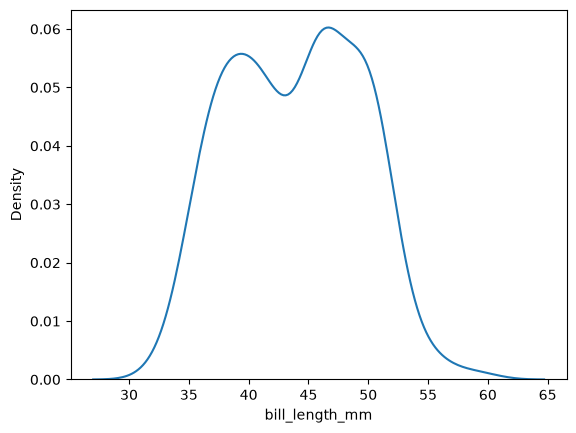

In [12]:
sns.kdeplot(data=df, x="bill_length_mm")
plt.show()

The two peaks we found are unmistakable here. The trade-off is that the curve is a
*smoothed estimate*: it hides where the actual observations are, it extends slightly past
the smallest and largest values in the data, and it has a smoothing setting of its own
(`bw_adjust`) that can over- or under-smooth just as bin count can. A histogram shows you
the data; a density plot shows you an interpretation of it.

A **boxplot** summarizes the same distribution as five numbers — the median, the middle
50% of the data (the box), the reach of the rest (the whiskers), and any outliers as
individual points:

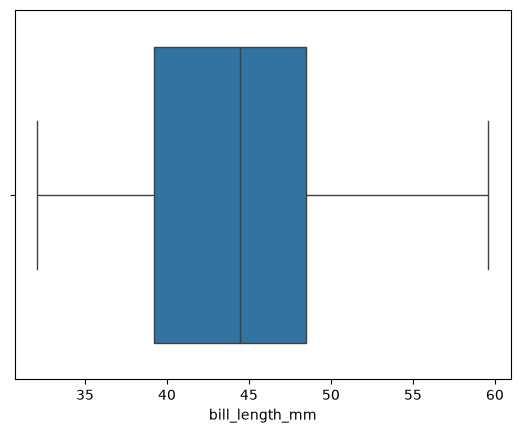

In [13]:
sns.boxplot(data=df, x="bill_length_mm")
plt.show()

The histogram and the boxplot answer different questions about the same column, so
neither one replaces the other. A histogram shows you the **shape**: where the values
pile up, whether there is one peak or several, and how the tails fall away. A boxplot
sets shape aside and reports **position, spread, and extremes** as a handful of exact
numbers — the median line, the box edges at the first and third quartiles, and whiskers
that reach out to 1.5 times the height of the box. Any observation past a whisker is
drawn as its own point, which is why a boxplot is the standard first look for
**outliers**: the Data Cleaning chapter later uses this same plot, and the same
1.5×IQR rule behind it, to decide which observations are worth investigating. Boxplots
are also compact, which is what makes them line up so well side by side when you compare
groups, as we do below.

The cost of that compactness is visible here: this boxplot does **not** tell you that
bill length is bimodal. The five numbers a boxplot reports would be nearly identical for
a single broad hump and for two separate peaks, so the most interesting feature of this
variable is invisible in it. The histogram has the opposite blind spot — it shows the two
peaks plainly but marks nothing as unusual, and reading a median or a quartile off it is
guesswork. Draw the histogram when you are asking what the distribution looks like, and
the boxplot when you are asking where the middle sits or which observations are far from
it.


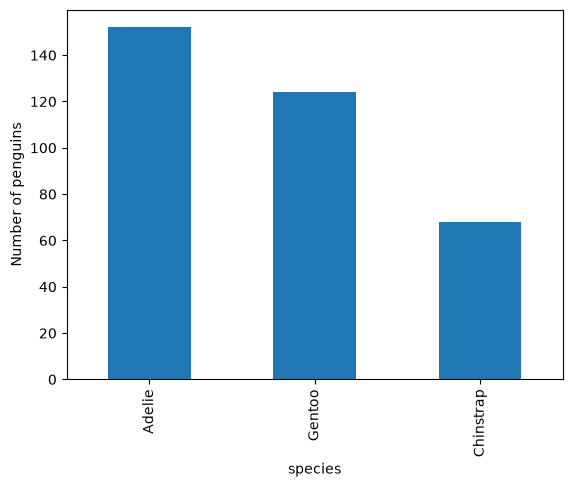

In [14]:
df["species"].value_counts().plot(kind="bar")
plt.ylabel("Number of penguins")
plt.show()

Read that chain left to right: take the `species` column, count how many times each value
appears, then draw the result as bars. Note that pandas needs you to do the counting
yourself; the plotting method just draws whatever numbers you hand it.

### With matplotlib

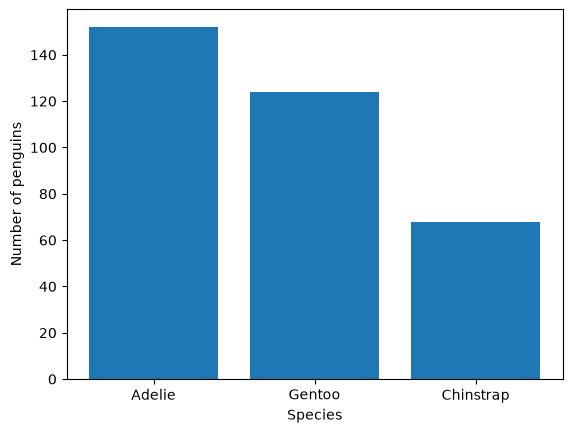

In [15]:
counts = df["species"].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()

`plt.bar` needs two things: the category labels and the bar heights. `counts.index` gives
the labels (`Adelie`, `Gentoo`, `Chinstrap`) and `counts.values` gives the heights. Again,
you count first and plot second.

### With seaborn

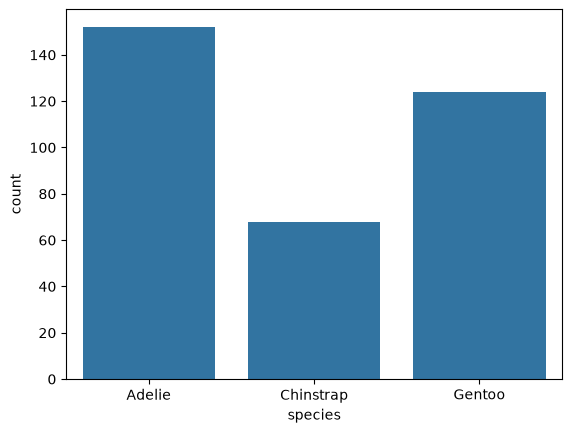

In [16]:
sns.countplot(data=df, x="species")
plt.show()

`countplot` does the counting *and* the drawing. This is the first place where seaborn's
design pays off: you never build an intermediate table.

::: {.callout-note}
## Ordering the bars

Bar categories have no natural order, so the library has to pick one. `value_counts()`
sorts by frequency (largest first), while `countplot` uses the order the values appear in
the data. Neither is wrong, but if the order carries meaning — largest to smallest, or a
fixed sequence like `Small, Medium, Large` — set it yourself with the `order` argument:

```python
sns.countplot(data=df, x="species", order=["Adelie", "Chinstrap", "Gentoo"])
```
:::

## Two numeric variables: the scatter plot

**Question:** do penguins with longer flippers also weigh more?

Two numeric variables means we are asking about a **relationship**, and the scatter plot
is the answer: one dot per penguin, positioned by both measurements at once.

### With pandas

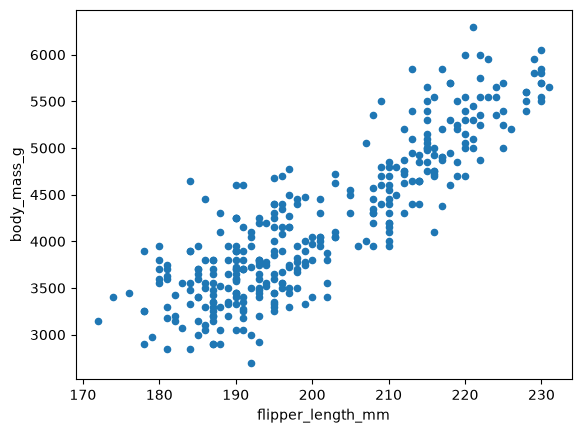

In [17]:
df.plot(kind="scatter", x="flipper_length_mm", y="body_mass_g")
plt.show()

This one is called on the whole DataFrame (`df.plot`), not a single column, because a
scatter plot needs two columns. You name them with `x` and `y`.

### With matplotlib

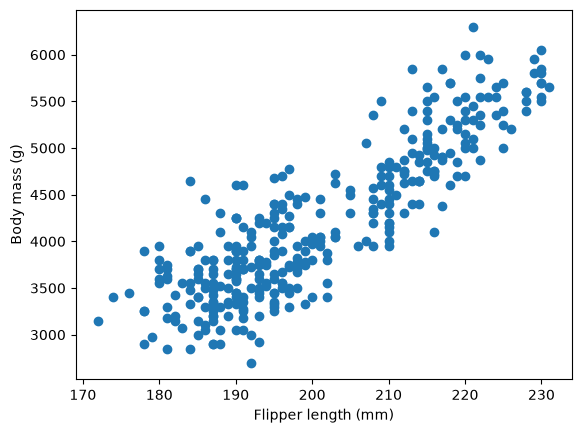

In [18]:
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()

`plt.scatter` takes the actual data — two Series, x first then y — rather than column
names.

### With seaborn

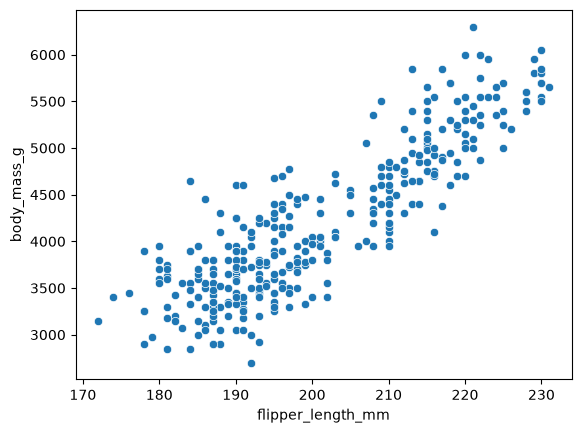

In [19]:
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g")
plt.show()

All three plots show the same clear pattern: flipper length and body mass rise together.
Longer-flippered penguins are heavier.

### Adding a third variable with color

Look closely at that scatter plot and you can see the points are not one single cloud —
there seem to be two or three clumps. And we still owe an answer to the question the
bill-length histogram raised: what are the two groups hidden inside it?

Both questions have the same suspected cause — species — and we can test it by bringing in
a third variable: color the points by it. This is where seaborn pulls decisively ahead.
One argument, `hue`:

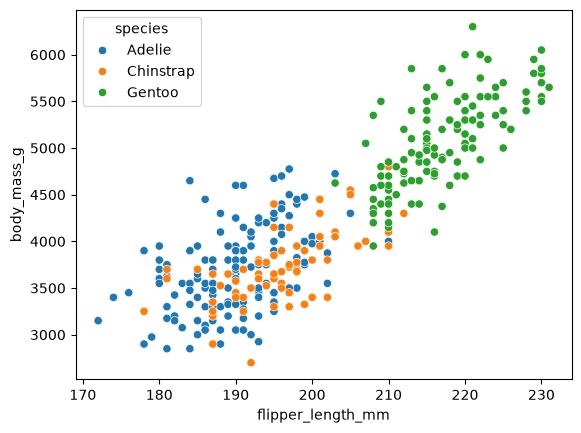

In [20]:
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.show()

There is the answer. `Gentoo` penguins are the heavy, long-flippered group; `Adelie` and
`Chinstrap` overlap almost entirely in mass and flipper length but separate clearly from
Gentoo.

`hue` works on the distribution plots too, which settles the bimodality question directly:

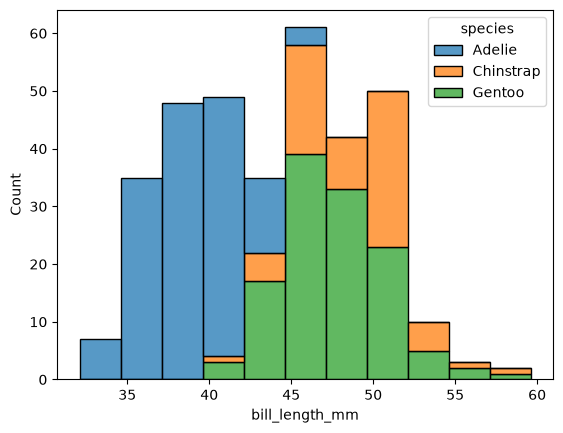

In [21]:
sns.histplot(data=df, x="bill_length_mm", hue="species", multiple="stack")
plt.show()

The left peak is almost entirely Adelie; the right peak is Chinstrap and Gentoo together,
with only a narrow band of overlap between them. Bill
length was never really bimodal — it was two different kinds of penguin measured into one
column. **A bimodal distribution is usually a hint that you have forgotten to split the
data by some group**, and `hue` is how you check.

The `multiple="stack"` argument stacks each species' bars on top of one another. Without
it, seaborn's default is `multiple="layer"`, which draws the three histograms on top of
each other semi-transparently — fine for two groups, but muddy where three overlap. The
other useful option is `multiple="dodge"`, which puts the groups' bars side by side.

`hue` works on essentially every seaborn function, and it accepts a numeric column too
(in which case you get a continuous color scale rather than a discrete legend). Two
related arguments split the data the same way but with a different visual channel:
`style` varies the marker shape and `size` varies the marker size.

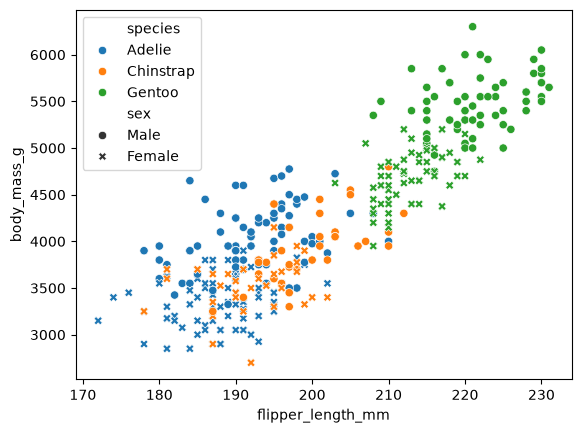

In [22]:
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", style="sex")
plt.show()

That plot is close to the limit of what one set of axes can carry — four variables and a
two-part legend. When a plot needs more, the answer is usually several plots rather than
more channels, which is exactly what the next chapter is about.

::: {.callout-note}
## The same thing in pandas and matplotlib

Coloring by category is possible in the other two libraries, but you have to build the
color mapping yourself: pick a color per species, then either plot each species
separately or construct a list of colors, one per row. The comparison is the point —
whenever a plot involves *groups*, seaborn is the tool that was designed for it.
:::

## Many numeric variables: the correlation heatmap

**Question:** the dataset has four numeric columns. Which pairs move together, and which
don't?

A scatter plot handles one pair at a time. Four columns make six pairs, and drawing six
scatter plots to find the interesting ones is tedious. The usual shortcut is to reduce
each pair to a single number — its **correlation** — and then show all of those numbers
at once as a heatmap.

You already know how to produce those numbers:
[`.corr()`](pandas_intermediate.ipynb#exploring-relationships-with-.corr), from the
Pandas Intermediate chapter, returns the correlation of every pair of numeric columns as
a DataFrame — a symmetric matrix with `1.00` down the diagonal and values running from
−1 (perfect negative) through 0 (no linear relationship) to +1 (perfect positive). As a
rough guide, magnitudes above 0.7 are strong, 0.3–0.7 moderate, and below 0.3 weak. What
is new in this chapter is turning that table into a picture.

One argument earns its place here. `numeric_only=True` tells `.corr()` to skip `species`,
`island`, and `sex`, since correlation is only defined for numbers and the call fails
without it — the same job the earlier chapter did by selecting the numeric columns first.
`.round(2)` is only for readability:


In [23]:
df.corr(numeric_only=True).round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


Four numeric columns give a four-by-four table, with each real correlation appearing
twice, once on either side of the diagonal. At this size the numbers are readable as they
stand; at ten or twenty variables the same table becomes a wall of digits.

### Drawing it

A heatmap replaces each number with a color, so the pattern arrives before you read
anything:


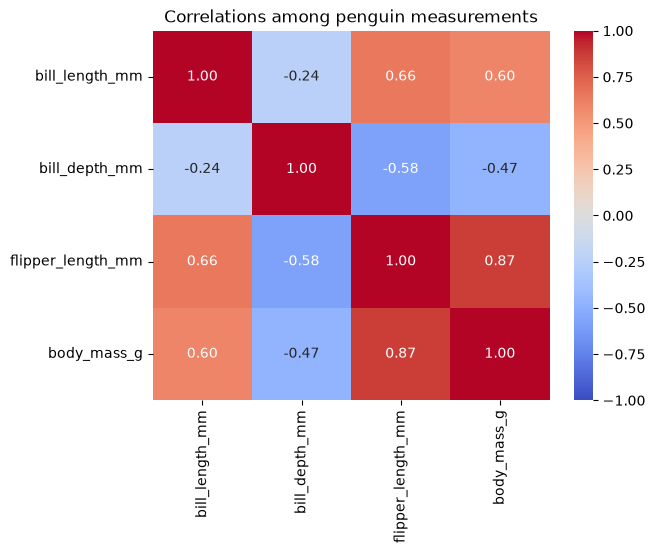

In [24]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlations among penguin measurements")
plt.show()

Four arguments are doing real work here, and the last three matter more than they look:

- `annot=True` prints the number inside each cell, and `fmt=".2f"` rounds it to two
  decimals. With a small matrix, always do this — the reader gets the color *and* the
  value.
- `cmap="coolwarm"` picks a **diverging** color scale: strong color at both ends, pale in
  the middle. This is the right choice because correlation has a meaningful midpoint at
  zero, and a diverging scale puts "no relationship" at the washed-out center where it
  belongs. Compare with the counts heatmap later in this chapter, which uses sequential
  `"Blues"` — counts start at zero and only go up, so they need a scale that runs from
  light to dark in one direction.
- `vmin=-1, vmax=1` pins the ends of the color scale to the full possible range. Without
  them, seaborn stretches the colors to fit whatever values happen to be present, so a
  matrix whose strongest correlation is 0.3 would be colored as intensely as one full of
  0.95s. **Setting `vmin`/`vmax` is what makes two heatmaps comparable.** For a diverging
  scale you can equivalently pass `center=0`.

Reading the plot: `flipper_length_mm` and `body_mass_g` are the most strongly related pair
at **0.87** — the relationship we already saw in the scatter plot. `bill_length_mm` is
moderately positive with both (0.66 and 0.60). And `bill_depth_mm` is the odd one out,
negatively correlated with everything: −0.58 with flipper length, −0.47 with body mass.

### Adding a regression line

The heatmap told us that `flipper_length_mm` and `body_mass_g` are the most strongly
related pair, at 0.87. A correlation that high, on variables whose scatter plot really
does look like a band around a straight line, is the situation where it is worth drawing
the line itself. Seaborn has a dedicated function for it, `regplot` — "regression plot":

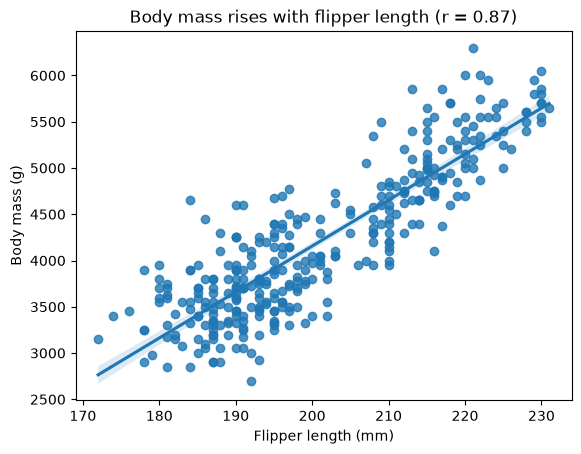

In [25]:
sns.regplot(data=df, x="flipper_length_mm", y="body_mass_g")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Body mass rises with flipper length (r = 0.87)")
plt.show()

`regplot` draws three things from that one call: the scatter points, the best-fitting
straight line through them, and a shaded band around the line. The band is a 95%
confidence interval for *where the line sits* — it is narrow in the middle of the data,
where there are many penguins, and flares at the edges, where there are few. It is not a
prediction interval, so do not read it as "95% of penguins fall in here."

The line makes the relationship quantitative rather than impressionistic: it slopes up by
roughly 50 g of body mass per millimetre of flipper, and the points sit close to it along
its whole length, which is what a correlation of 0.87 looks like in practice.

::: {.callout-important}
## Only draw a line where a line belongs

A regression line is a claim: *this relationship is linear*. `regplot` will happily fit a
straight line to any two numeric columns, including ones where a straight line is
nonsense, and the line will look just as authoritative. So check the scatter plot first
and add the line only when the cloud of points genuinely runs in a straight band.

The order matters. **Scatter plot first, line second** — never add a line because a
correlation coefficient was large. The coefficient itself only measures straightness, so
using it to justify a straight line is circular reasoning.

Two escape hatches when the relationship is curved rather than straight:

```python
sns.regplot(data=df, x="...", y="...", order=2)      # fit a parabola instead
sns.regplot(data=df, x="...", y="...", lowess=True)  # follow the data, no formula
```
:::

Useful arguments:

| Argument | What it does |
|---|---|
| `ci=None` | Drop the shaded band — good when overlaying several lines |
| `scatter=False` | Draw only the line, onto a scatter plot you already made |
| `order=2` | Fit a quadratic instead of a straight line |
| `lowess=True` | Fit a flexible smooth curve instead of any fixed formula |
| `line_kws={"color": "black"}` | Style the line |
| `scatter_kws={"alpha": 0.4}` | Style the points — useful when they overlap |

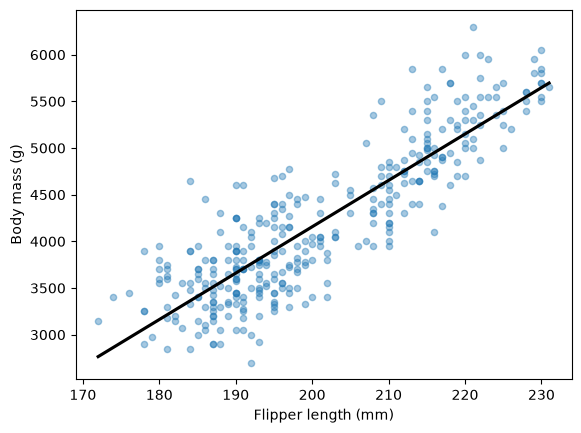

In [26]:
sns.regplot(data=df, x="flipper_length_mm", y="body_mass_g",
            ci=None,
            scatter_kws={"alpha": 0.4, "s": 20},
            line_kws={"color": "black"})
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()

Note one thing `regplot` cannot do: it has **no `hue` argument**. To fit a separate line
per group, you either overlay several `regplot` calls — which we do in a moment — or use
seaborn's `lmplot`, a figure-level function that we save for the next chapter, because it
creates and owns its own figure.

### Three warnings

Correlation is the most over-trusted number in introductory statistics. Three things it
does not tell you:

**It only sees straight lines.** A correlation near zero means no *linear* trend, not no
relationship. Two variables can follow a perfect U-shape and still have a correlation of
about 0. This is why you plot the data rather than only computing the number.

**It does not mean causation.** Flipper length and body mass correlate at 0.87, but
neither causes the other; both reflect how big the penguin is, and much of the spread
comes from species.

**A correlation over a mixed population can point the wrong way.** That negative
`bill_length` / `bill_depth` correlation of −0.24 is the clearest warning in this
dataset. Compute it within a single species and it turns **positive** — about +0.39 for
Adelie. The overall negative number is an artifact of mixing three species with
differently shaped bills, not a fact about any penguin. A reversal like this is called
**Simpson's paradox**, and you can see it happen by drawing the scatter plot with
`hue="species"`:

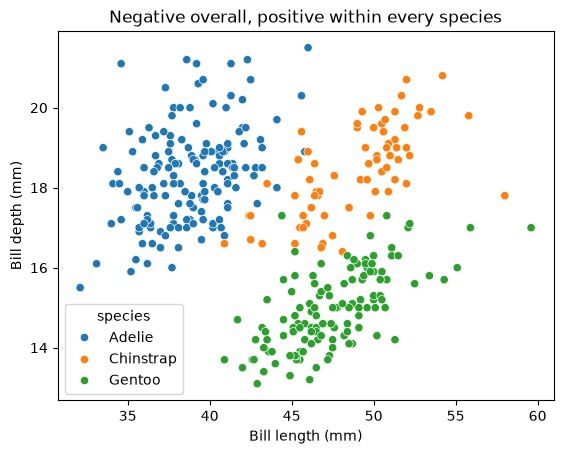

In [27]:
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.title("Negative overall, positive within every species")
plt.show()

The cloud as a whole slopes downward, while each colored group slopes upward. Regression
lines make this impossible to miss. First, the line a correlation of −0.24 would have you
draw — one line over all 344 penguins at once:

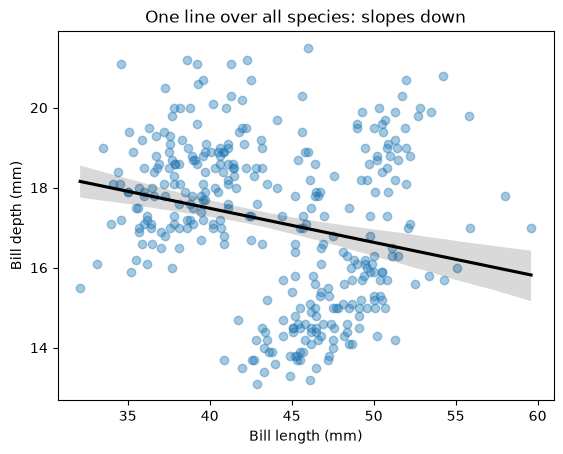

In [28]:
sns.regplot(data=df, x="bill_length_mm", y="bill_depth_mm",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.title("One line over all species: slopes down")
plt.show()

Now one line per species, drawn onto the same axes. Since `regplot` has no `hue`, we call
it once per species, each time on just that species' rows:

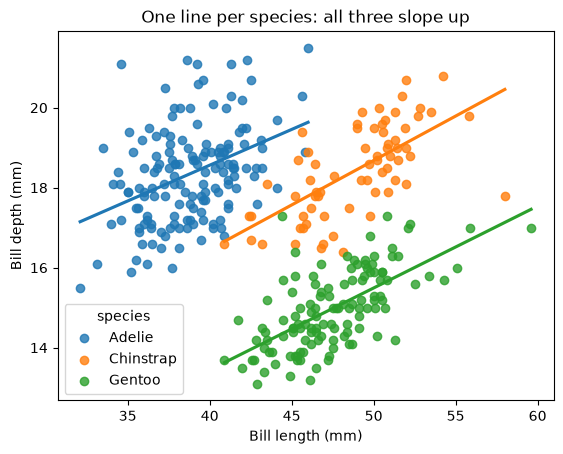

In [29]:
for name in df["species"].unique():
    subset = df[df["species"] == name]
    sns.regplot(data=subset, x="bill_length_mm", y="bill_depth_mm",
                label=name, ci=None)

plt.legend(title="species")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.title("One line per species: all three slope up")
plt.show()

Three upward lines, from data whose overall correlation is negative. The trick is that
`df["species"].unique()` lists the three species names, and `df[df["species"] == name]`
keeps only the rows matching one of them — so each `regplot` call sees a single species
and fits a line to it alone. Drawing three plotting calls onto one set of axes works the
same way the layered box-and-points plot later in this chapter does: each call adds to
whatever is already there.

The reason for the reversal is visible in the plot. Gentoos sit low and to the right —
long, shallow bills — while Adelies sit high and to the left. That between-species offset
is steeply downward and it swamps the gentle upward trend inside each group. The single
black line is not describing any penguin; it is describing the arrangement of the three
species.

No correlation coefficient can warn you about this, and neither can a single regression
line. Treat a correlation heatmap as a way of deciding **which scatter plots to draw
next**, never as a substitute for drawing them — and before you fit any line, ask whether
your data is one population or several stacked together.

## Numeric by categorical: comparing groups

**Question:** which species is heaviest?

This pairs one numeric variable with one categorical variable, so we want the numeric
variable's distribution *within each group*, drawn side by side for comparison.

### Boxplots by group

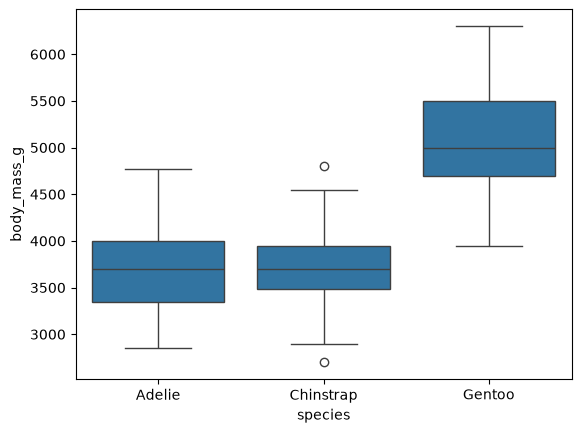

In [30]:
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.show()

Categorical variable on `x`, numeric variable on `y`, and seaborn draws one box per
species. This is what boxplots are best at: three distributions, directly
comparable, in one line of code. Gentoos are clearly heavier, and the Adelie and
Chinstrap distributions sit almost on top of each other.

The equivalent in `pandas` is:

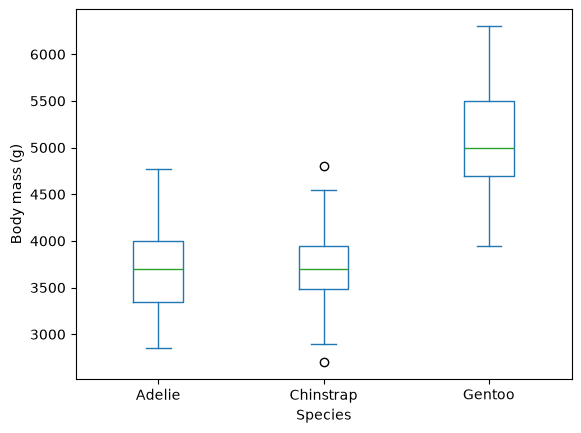

In [31]:
df.plot(kind="box", column="body_mass_g", by="species")
plt.suptitle("")               # pandas adds a figure-level title
plt.title("")                  # ...and an axes-level one; clear both
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.show()

Note the two empty-string calls. When you use `by=`, pandas writes *two* titles onto the
figure — the grouping variable as a suptitle and the column name as an axes title — so
getting a clean plot means clearing both. In bare `matplotlib` it is worse: you would have
to split the data into three separate arrays yourself and pass them as a list to
`plt.boxplot`. Use seaborn for this.

### Violin plots

A violin plot replaces each box with a mirrored density curve, so you see the *shape* of
each group's distribution rather than just its five summary numbers:

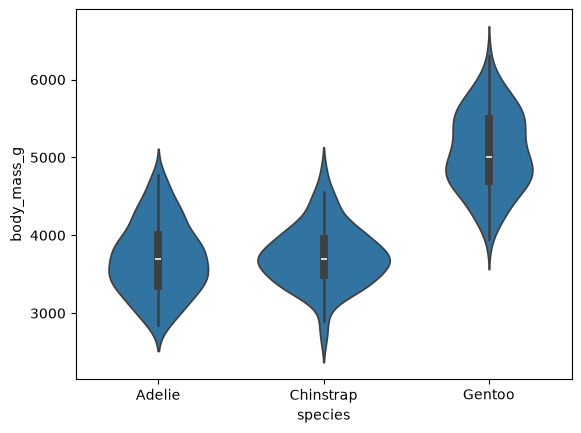

In [32]:
sns.violinplot(data=df, x="species", y="body_mass_g")
plt.show()

Here the violins tell us something the boxplot could not: the Adelie distribution has a
single broad peak, while Gentoo mass is spread more evenly across a wider range. Use a
violin plot when the shape matters and you have enough observations per group (a few
dozen at least) for the curve to be trustworthy.

### Bar chart of means

A bar chart can also compare a numeric variable across groups — but a bar has only one
height, so the many values in each group have to be reduced to a single number first.

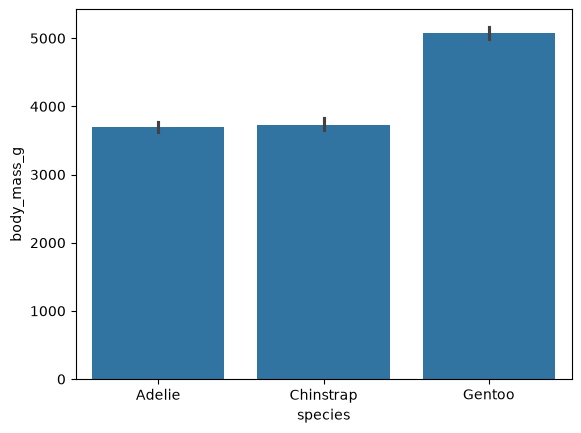

In [33]:
sns.barplot(data=df, x="species", y="body_mass_g")
plt.show()

::: {.callout-important}
## Aggregation is happening, even though you didn't ask for it

That command had no averaging step in it, yet each bar is a single height. Seaborn
**aggregated the data for you**: the bar height is the *mean* body mass of all penguins
of that species, and the thin vertical line on each bar is a 95% confidence interval for
that mean.

This is worth stopping on, because it is invisible in the code. A bar chart of a numeric
variable by category *must* reduce many values to one, so some aggregation is
unavoidable — seaborn just picks a sensible default (the mean) instead of making you say
so. You will learn to do this aggregation explicitly with `.groupby()` in a later
chapter, and at that point you will be able to compute these exact bar heights yourself.
For now, the thing to remember is that **a bar height is an average over a whole group,
not a single observation.**

The same hidden work is going on elsewhere in this chapter. `sns.histplot` bins the data
and counts the rows in each bin. `sns.boxplot` computes a median and quartiles per group.
`sns.countplot` counts rows per category. In every case the library is summarizing your
data before it draws.
:::

When you have one numeric and one categorical variable, prefer a boxplot or violin plot
over a bar of means. The bar throws away almost everything — you cannot see the spread,
the shape, or the outliers, and two groups with identical means can have completely
different distributions. Reach for the bar chart when the average genuinely *is* the
quantity of interest.

## Two categorical variables

**Question:** are the three species spread evenly across the three islands, or does each
island have its own?

Two categorical variables means counting the combinations. The clearest plot is a grouped
bar chart, which in seaborn is `countplot` plus a `hue`:

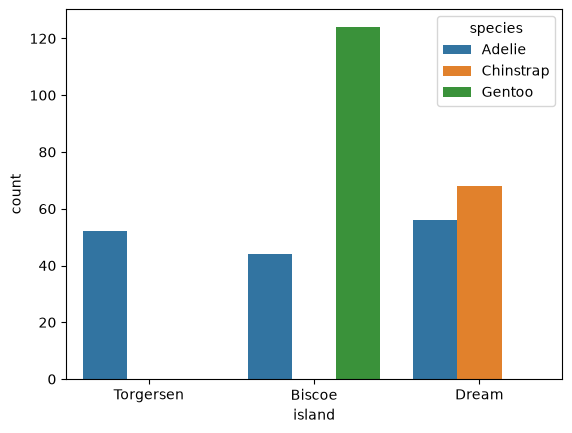

In [34]:
sns.countplot(data=df, x="island", hue="species")
plt.show()

The structure is striking. Adelie penguins live on all three islands, but Gentoos appear
only on Biscoe and Chinstraps only on Dream; Torgersen has nothing but Adelies. Species
and island are strongly related, which is worth knowing before comparing anything across
islands — a difference in body mass between Biscoe and Torgersen would really be the
Gentoo/Adelie difference wearing a disguise.

::: {.callout-note}
## The pandas version needs a method you haven't met yet

To make this plot in pandas, you first need a table of counts for every
island–species combination. That is what `pd.crosstab` builds: you give it two columns
and it returns a small DataFrame whose rows are the values of the first and whose columns
are the values of the second, with counts in the cells.

In [35]:
pd.crosstab(df["island"], df["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


Read the cell in row `Biscoe`, column `Gentoo`: 124 penguins were both. The zeros show
the combinations that never occurred. Once the table exists, plotting it is the usual
`.plot()` call — and because the table has three columns, pandas draws one bar per column
within each row:

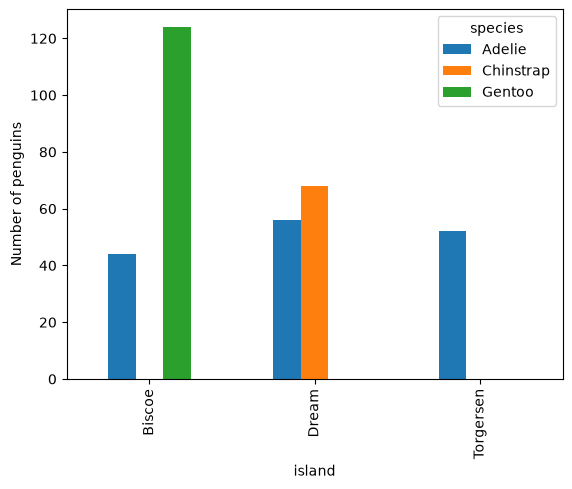

In [36]:
pd.crosstab(df["island"], df["species"]).plot(kind="bar")
plt.ylabel("Number of penguins")
plt.show()

You are not expected to reach for `crosstab` on your own yet; it is here so you can see
that the seaborn version is doing the same counting internally.
:::

When both variables have many categories, a grouped bar chart becomes a forest of thin
bars. A **heatmap** scales better — it shows the same counts as color intensity, exactly
as the correlation heatmap did for correlations:

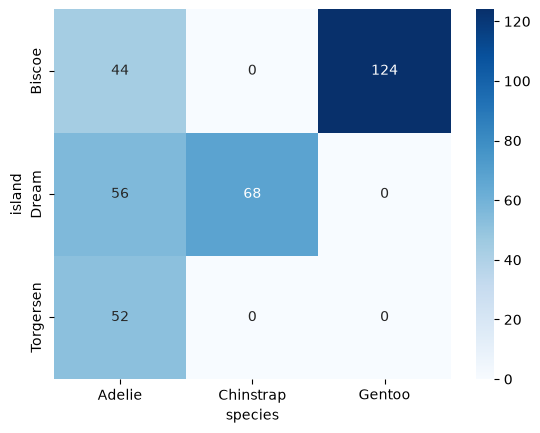

In [37]:
sns.heatmap(pd.crosstab(df["island"], df["species"]), annot=True, fmt="d", cmap="Blues")
plt.show()

`annot=True` prints the number in each cell, and `fmt="d"` formats those numbers as
integers rather than the `".2f"` we used for correlations — these cells are counts, so
`44.00` would be silly.

The colormap choice differs too, and for a reason worth remembering. Counts are
**sequential**: they start at zero and only increase, so `"Blues"` runs light-to-dark in
one direction. Correlations are **diverging**: they run from −1 through a meaningful zero
to +1, so `"coolwarm"` puts a pale color at the midpoint and strong colors at both
extremes. Using a diverging map for counts, or a sequential map for correlations, makes a
plot that actively misleads — the reader's eye looks for a midpoint that isn't there, or
misses the one that is.

| Kind of data | Colormap | Examples |
|---|---|---|
| Sequential (low → high, no midpoint) | `"Blues"`, `"viridis"` | Counts, totals, prices |
| Diverging (meaningful center) | `"coolwarm"`, `"RdBu_r"` | Correlations, change from a baseline, profit vs. loss |

## Two numeric variables in order: the line plot

None of the penguin columns is a time series, so this row of the decision table needs a
different example. The rule is what matters: **use a line plot when the x-values have a
meaningful order**, because a line asserts that the space between two points is real.

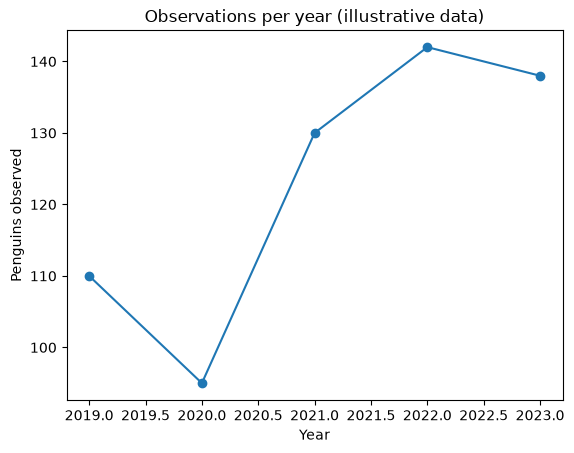

In [38]:
years = [2019, 2020, 2021, 2022, 2023]
observations = [110, 95, 130, 142, 138]

plt.plot(years, observations, marker="o")
plt.xlabel("Year")
plt.ylabel("Penguins observed")
plt.title("Observations per year (illustrative data)")
plt.show()

Note that `plt.plot` accepts plain Python lists — no DataFrame needed. The `marker="o"`
argument puts a dot at each actual data point, which is a good habit: it shows your
reader where the measurements are and where the line is just interpolation.

The seaborn equivalent for data in a DataFrame is `sns.lineplot(data=df, x=..., y=...)`,
and in pandas, `df.plot(kind="line", x=..., y=...)`.

A line plot of unordered categories is one of the most common beginner mistakes. Nothing
stops you from drawing a line across `Adelie`, `Chinstrap`, `Gentoo` — the code runs
fine — but it implies a trend through a sequence that could be rearranged at will. If the
x-axis could be shuffled without losing information, use bars.

## Finishing a plot

An unlabeled plot is not finished. Whichever library drew it, these `matplotlib`
commands will adjust it, because all three ultimately draw through `matplotlib`:

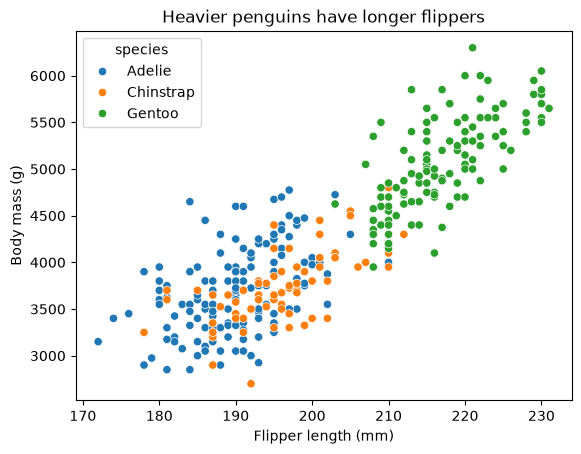

In [39]:
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species")

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Heavier penguins have longer flippers")
plt.show()

The commands you will use constantly:

| Command | What it does |
|---|---|
| `plt.xlabel(...)`, `plt.ylabel(...)` | Label the axes — **include units** |
| `plt.title(...)` | Title the plot |
| `plt.xlim(...)`, `plt.ylim(...)` | Set the axis range |
| `plt.legend(title=...)` | Adjust the legend |
| `plt.xticks(rotation=45)` | Rotate tick labels so long names don't overlap |
| `plt.figure(figsize=(w, h))` | Set the figure size in inches — **before** drawing |
| `plt.savefig("name.png", dpi=300)` | Save to a file — **before** `plt.show()` |

Two ordering traps in that table, both of which produce a confusing result rather than an
error:

- `plt.figure(figsize=...)` must come *before* the plotting command, since it creates the
  figure that the plot goes into.
- `plt.savefig(...)` must come *before* `plt.show()`. `plt.show()` closes out the current
  figure, so saving afterwards writes a blank image.

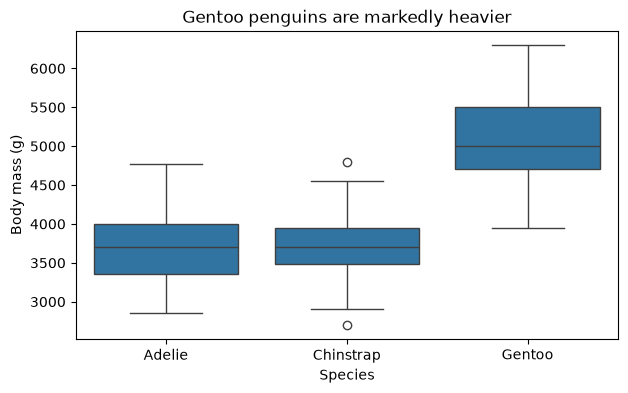

In [40]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.title("Gentoo penguins are markedly heavier")
plt.show()

Seaborn also controls overall appearance with themes, which apply to every plot you draw
afterwards:

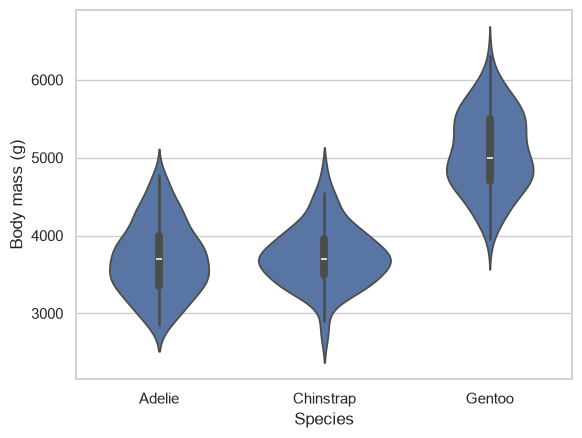

In [41]:
sns.set_theme(style="whitegrid")

sns.violinplot(data=df, x="species", y="body_mass_g")
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.show()

In [42]:
#| echo: false
sns.set_theme()  # restore the default for the rest of the chapter

Other `style` options are `"darkgrid"` (seaborn's default), `"white"`, `"dark"`, and
`"ticks"`. Setting a theme once at the top of a notebook is a good way to keep every
figure in a report looking consistent.

::: {.callout-note collapse="true"}
## Going further: making a plot look good

A chapter has room for the arguments that decide what a plot means, and little room for
the ones that decide how it looks. Every plot here can be made considerably handsomer
without changing what it claims, and seaborn documents that side of the work in three
places worth a browse when you have a plot you care about:

- [Controlling figure aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html) — themes, grids, spines, and the `context` setting that scales every element at once for a slide or a printed page.
- [Choosing color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html) — which palette suits categories, an ordered scale, or a diverging one, and which choices stay readable for colour-blind readers. Matplotlib's [colormap reference](https://matplotlib.org/stable/users/explain/colors/colormaps.html) is the companion for `cmap=`.
- [The example gallery](https://seaborn.pydata.org/examples/index.html) — finished figures with their source code. Finding one that resembles what you want and reading its code is the fastest way to learn the styling arguments.

None of this is required for the practice activity, and none of it repairs a plot that
answers the wrong question.
:::

## Making plots honest

A plot is an argument, and it is easy to make a misleading one by accident.

**Start bar charts at zero.** A bar's *length* is what encodes the value, so cutting off
the bottom of the axis exaggerates differences. Compare:

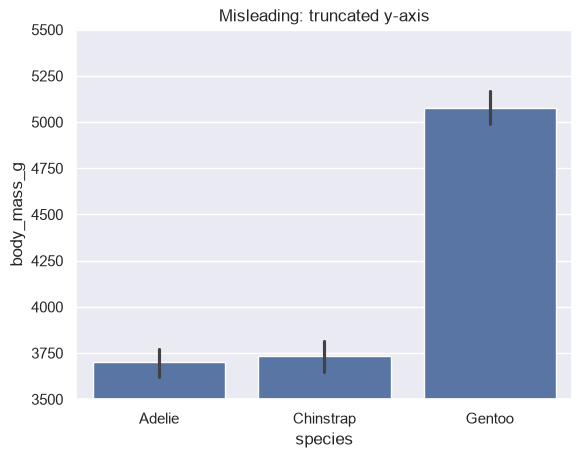

In [43]:
sns.barplot(data=df, x="species", y="body_mass_g")
plt.ylim(3500, 5500)
plt.title("Misleading: truncated y-axis")
plt.show()

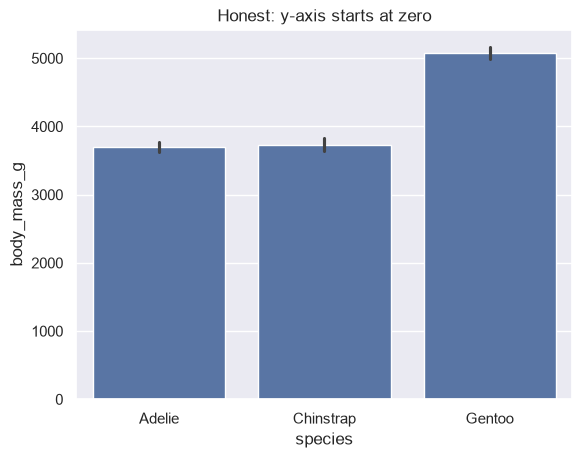

In [44]:
sns.barplot(data=df, x="species", y="body_mass_g")
plt.title("Honest: y-axis starts at zero")
plt.show()

The first plot makes Gentoos look several times heavier than Adelies. In fact the means
are about 5076 g and 3701 g — Gentoos are roughly 37% heavier, a real difference but not
the overwhelming one the truncated axis suggests. Scatter and line plots, where position
rather than length carries the meaning, do not need a zero baseline.

**Label your axes and include units.** `body_mass_g` is a column name, not a label.
"Body mass (g)" tells the reader what they are looking at.

**Don't hide the sample size.** A bar chart of means looks equally confident whether a
group has 300 observations or 3. A boxplot or violin at least shows the spread; adding
the raw points is even better, and one of the nicest things seaborn does is let you layer
plots by simply drawing one after the other:

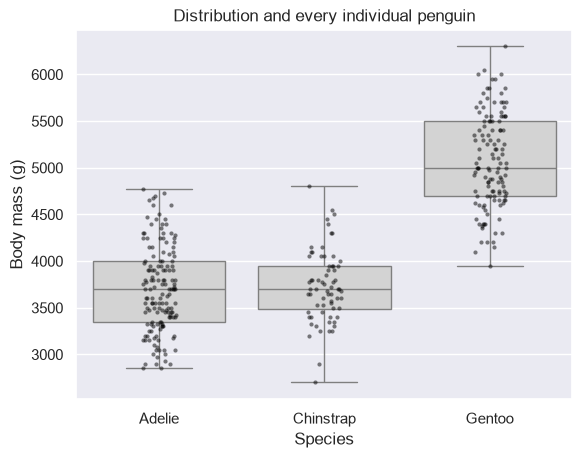

In [45]:
sns.boxplot(data=df, x="species", y="body_mass_g", whis=(0, 100), color="lightgray")
sns.stripplot(data=df, x="species", y="body_mass_g", size=3, color="black", alpha=0.5)
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.title("Distribution and every individual penguin")
plt.show()

Two seaborn calls in a row drew onto the same axes, because each one adds to the plot that
is already there rather than starting a new one. `alpha=0.5` makes the points
semi-transparent so overlapping penguins are still visible — a useful trick any time
points pile up.

**Say what the plot is for.** A title that states the finding ("Gentoo penguins are
markedly heavier") is more useful than one that states the mechanics ("Body mass by
species").

## Summary Cheat Sheet {#summary-cheat-sheet}

Choosing a plot comes down to counting your variables and checking their types:

| Variables | Plot | Seaborn function |
|---|---|---|
| One numeric | Histogram / density / boxplot | [`histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html), [`kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html), [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) |
| One categorical | Bar chart of counts | [`countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html) |
| Two numeric | Scatter plot | [`scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) |
| Two numeric, roughly linear | Scatter plot with a fitted line | [`regplot`](https://seaborn.pydata.org/generated/seaborn.regplot.html) |
| Two numeric, x ordered | Line plot | [`lineplot`](https://seaborn.pydata.org/generated/seaborn.lineplot.html) |
| Several numeric | Correlation heatmap | [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) on `df.corr()` |
| Numeric + categorical | Grouped boxplot / violin / bar of means | [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html), [`violinplot`](https://seaborn.pydata.org/generated/seaborn.violinplot.html), [`barplot`](https://seaborn.pydata.org/generated/seaborn.barplot.html) |
| Two categorical | Grouped bar chart / heatmap | `countplot(hue=...)`, [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) |
| One extra variable | Add color, shape, or size | `hue=`, `style=`, `size=` |

Each function name above links to its own documentation page. This chapter uses only
the arguments that change what a plot *says*; those pages list the rest — the ones that
change how it looks — with a worked example for each.

And choosing a library comes down to what the plot has to do:

- **`pandas`** — `df["col"].plot(kind=...)` or `df.plot(kind=..., x=..., y=...)`. Fastest
  for a quick look at a DataFrame you already have.
- **`matplotlib`** — `plt.hist`, `plt.scatter`, `plt.bar`, `plt.plot`. Takes raw data, not
  column names. Maximum control; you write every label yourself.
- **`seaborn`** — `sns.func(data=df, x="col", y="col", hue="col")`. The right default for
  anything involving groups, distributions, or statistics.

Because `pandas` and `seaborn` both draw through `matplotlib`, the `plt.*` commands for
labels, titles, sizes, and saving work on all three.

## Practice Activity: Choose, Draw, and Defend a Plot {#practice-activity-choose-draw-and-defend-a-plot}

**Goal:** Pick the right plot for four questions about one dataset, draw each one, and say what it shows and what it hides.

**File:** `activity08.ipynb` from the [practice kit](downloads/data-visualization-1-practice.zip).

**Submit:** `activity08.html` through the final upload question in the Data Visualization I Canvas quiz.

**This section contains the complete activity instructions.** The starter loads the data and supplies spaces to record your work. Open `activity08.ipynb` from the folder prepared in [Set Up Your Chapter Files](#set-up-your-chapter-files), using the same project environment. The worked examples above are preparation, not additional submission requirements.

You will use the same Palmer penguins dataset the chapter uses, loaded the same way, so the activity needs no data file of its own.

### A. One Numeric Variable, and What the Bins Decide {.unnumbered}

- Replace `Your Name` in the opening Raw cell's `author` field. Run the setup cell; it must report the shape `(344, 7)`.
- Draw `flipper_length_mm` as a histogram with 5 bins, then 15, then 40, and describe the shape each one shows in a sentence. Say which bin count you would report, and why.
- Report how many penguins the histogram left out because the column is missing, and show the code that told you. Nothing on the plot itself says so.
- Draw the same column as a density curve and as a box plot. Name one thing each of the three views shows that the other two hide.

### B. One Categorical Variable, in Two Libraries {.unnumbered}

- Count the penguins on each island and draw the counts as a bar chart, with the bars in decreasing order of count.
- Draw that same bar chart twice: once with pandas and once with seaborn.
- In two or three sentences, compare the two versions: which ordered the bars with less work, which labelled the axes for you, and which you would use for a quick look versus for a report.

### C. Two Numeric Variables, and a Line Only Where It Belongs {.unnumbered}

- Display the correlation matrix of the four numeric columns and draw it as a heatmap with the colour scale pinned to the full −1 to +1 range. Read off the correlation between `bill_depth_mm` and `body_mass_g` and interpret its sign in a sentence.
- Draw the scatter plot of those two columns, then redraw it with `hue="species"`.
- Fit a regression line to the pooled data with `sns.regplot`, then say what happens to the relationship inside each species. Explain what the pooled line claims and why that claim is wrong for these penguins.
- Finish with one sentence on what this means for reading a correlation computed over a mixed population.

### D. Groups, Hidden Aggregation, and a Finished Plot {.unnumbered}

- Compare `body_mass_g` across the three species with a box plot, and then with `sns.barplot`.
- The bar chart shows one height per species although you never averaged anything. Say what seaborn computed for you, what the thin vertical line on each bar represents, and which of the two plots you would put in a report.
- Redraw your chosen plot as a finished figure: both axes labelled with units, a title that states a finding rather than the mechanics, and a deliberate figure size. Save it as a 300-dpi PNG and confirm the saved file is not blank.
- Explain in one sentence why a bar chart of these means has to start at zero.

### Render and Submit {.unnumbered}

Restart the kernel, run all cells in order, resolve unexpected errors, and save. Include your plots, outputs, and explanations for A–D, and a short Markdown completion note. From `stat303-data-visualization-1` in the terminal, run:

```text
quarto render activity08.ipynb --to html
```

Follow the [Quarto refresher](vscode_setup.ipynb#render-and-submit-with-quarto): inspect the HTML and a copy opened outside the project folder, and confirm that every plot appears and your name is on the report. Upload only `activity08.html` to the Data Visualization I Canvas quiz; keep your notebook locally.

**HTML grading (16 points):** bin choices, the missing-value count, and the three views of one variable (4); the ordered count chart in both libraries with a justified preference (3); correlation, heatmap, grouped scatter, and the critique of the pooled line (5); group comparison, the aggregation seaborn performed, and a finished honest figure (3); name, readable report, and completion note (1).

## Extended Practice {#extended-practice}

These longer exercises are additional practice, not requirements for the Canvas quiz.
Work in a separate notebook beside your activity and load the data the way the chapter
does. Include your code, plots, and explanations.

### Violin against Box

Compare `flipper_length_mm` across the three species with a box plot and then with a
violin plot. Name one thing each plot shows that the other does not, and describe a
distribution where the choice between them would change a reader's conclusion.

### A Heatmap That Hides Its Scale

Build the correlation heatmap again, but leave out `vmin` and `vmax` and change the
colormap to `"Blues"`. Name two specific ways the result is harder to read than the
version in this chapter, and say what a reader could wrongly conclude from it.

### The Weakest Pair, and the Shaded Band

Use the correlation heatmap to pick the pair of numeric columns with the *weakest*
correlation, and draw that pair with `sns.regplot`. Would you report this line to
someone? Explain what the shaded band around it is doing, and why a fitted line can
mislead here even though the code ran without complaint.

### A Line Where a Line Does Not Belong

Someone shows you a line plot with `species` on the x-axis and mean `body_mass_g` on the
y-axis, and argues that it shows a trend. Draw that plot, explain what is wrong with it,
and draw the plot they should have used instead.

## Before You Move On {#before-you-move-on}

The habit to carry forward is choosing before drawing: count the variables, check their
types, and let the question pick the plot. Reach for the library that fits the job —
pandas for a glance at a DataFrame you already have, seaborn for anything involving
groups or distributions, and `plt.*` for the labels, size, and saving, whichever library
drew the picture.

The plotting libraries are also quietly **summarizing** your data — binning it, counting
it, averaging it — before they draw a single pixel. Understanding what a plot computed is
as important as knowing which plot to pick.

For any plot you make or read, you should be able to answer five questions without
redrawing it:

1. What question is this plot answering, and do the variable types fit that question?
2. What did the library compute before it drew — bins, counts, means, quartiles, a fitted line?
3. How many observations are missing from the picture because a value was missing, and where did that number come from?
4. Does the pattern in the pooled data still hold inside each group?
5. Would a reader who saw only this picture reach the conclusion the data supports — axes labelled with units, a title that states the finding, and bars starting at zero?

Continue to [Data Visualization II](data_viz_2.ipynb), where
several plots are combined into one figure so that groups and variables can be compared
side by side.

References: [seaborn function overview](https://seaborn.pydata.org/tutorial/function_overview.html),
[distributions tutorial](https://seaborn.pydata.org/tutorial/distributions.html),
[`histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html),
[`regplot`](https://seaborn.pydata.org/generated/seaborn.regplot.html),
[`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html),
[pandas plotting](https://pandas.pydata.org/docs/user_guide/visualization.html),
[matplotlib pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html), and the
penguin measurements of [Gorman, Williams, and Fraser (2014)](https://doi.org/10.1371/journal.pone.0090081).